In [1]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from src.projections_.targets import merge_all_traj
from src.datasets.RefinitivDataset import RefinitivDataset
from src.datasets.utils import fill_missing_CF12

# Config

In [2]:
from config import load_config
### 2. Load Stated Targets Data
project_dir = Path().cwd()
config_file = load_config("./config.toml")
raw_data_dir = project_dir / "data" / "raw"
# Load mappings
gspt2gspt_path = Path("./data/raw/mappings/gspt2gspt.json")
mappings = config_file.mappings
gspt2gspt_path = raw_data_dir / mappings.gspt2gspt
historical_data = config_file.historical_data

Read historical BU emissions

In [3]:
from src.datasets.EmissionFactors   import EmissionFactors
from src.datasets.GSPTDataset import GSPTDataset
import joblib
from src.projections_.projections import get_historical_bu_emissions
# Load model from BU_results folder
model_path = Path("./BU_results/models/BU_single_OLS.joblib")
model = joblib.load(model_path)
prod_dir = raw_data_dir / "production"
oecd_capa_fpath = raw_data_dir / historical_data.macro.oecd_capa
wsa_prod_path = raw_data_dir / historical_data.macro.wsa_prod
emission_factors = config_file.emission_factors
energy_mix_path = raw_data_dir / emission_factors.energy_mix
parent_group_map_path = raw_data_dir / mappings.parent_group_map
with open(parent_group_map_path, "r") as f:
    parent_group_map = json.load(f)
# asset level data
gspt = GSPTDataset(data_path=raw_data_dir / historical_data.asset_level_data,
        missing_years_path=raw_data_dir / historical_data.missing_years,
        gspt2gspt_path=gspt2gspt_path,
        parent_group_map_path=parent_group_map_path,
        version_year=2023) 
EF = EmissionFactors(wsa_path=raw_data_dir / emission_factors.wsa,
                jrc_22_path=raw_data_dir / emission_factors.jrc,
                sci_path=raw_data_dir / emission_factors.sci,
                EU_27_path=raw_data_dir / mappings.EU_27,
                huizhong_path=raw_data_dir / emission_factors.huizhong,
                )
# Historical bottom-up 
agg_bu_histo, group_bu_histo, adj_factor, prod = get_historical_bu_emissions(gspt=gspt,
                            EF=EF,
                            prod_dir=prod_dir,
                            global_capa_path=oecd_capa_fpath,
                            global_prod_wsa_path=wsa_prod_path,
                            start_year=2019,
                            end_year=2022,
                            energy_mix_path=energy_mix_path,
                            parent_group_map=parent_group_map,
                            model=model,
                            gspt2gspt_path=gspt2gspt_path)

c:\Users\hamada.saleh\Documents\Python Scripts\bottom_up_alignment\src\feature_eng\plant_features.py:535: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df["Economy"] = filtered_df["Economy"].replace(oecd2wsa)
c:\Users\hamada.saleh\Documents\Python Scripts\bottom_up_alignment\src\feature_eng\plant_features.py:535: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df["Economy"] = filtered_df["Economy"].replace(oecd2wsa)
c:\Users\hamada.saleh\Documents\Python Scripts\bottom_up_alignment\src\featu

Removing 0.0 rows with zero emissions


c:\Users\hamada.saleh\Documents\Python Scripts\bottom_up_alignment\.pixi\envs\default\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [4]:
nze_path = "./BU_results/plant_level_data/nze_nze_elec_company_UR_company_aggregated.csv"
aps_path = "./BU_results/plant_level_data/aps_aps_elec_company_UR_company_aggregated.csv"
steps_path = "./BU_results/plant_level_data/steps_steps_elec_company_UR_company_aggregated.csv"

# Read the scenario files
nze_company = pd.read_csv(nze_path)
aps_company = pd.read_csv(aps_path) 
steps_company = pd.read_csv(steps_path)

# Add 2022 historical emissions to each dataframe
historical_2022 = group_bu_histo[group_bu_histo['year'] == 2022].copy()
historical_2022 = historical_2022[['Group', 'year', 'BU emissions']]
historical_2022 = historical_2022.rename(columns={'BU emissions': 'BU emissions (company_UR)'})

# Add 2022 data to each scenario df
nze_company = pd.concat([historical_2022, nze_company])
aps_company = pd.concat([historical_2022, aps_company]) 
steps_company = pd.concat([historical_2022, steps_company])

In [5]:
nze_company.dtypes

Group                                  object
year                                    int64
BU emissions (company_UR)             float64
emissions                             float64
production                            float64
capacity                              float64
emissions_low                         float64
emissions_high                        float64
log_Attributed emissions              float64
log_Attributed emissions_low          float64
log_Attributed emissions_high         float64
log BU emissions (company_UR)         float64
log BU emissions_low (company_UR)     float64
log BU emissions_high (company_UR)    float64
BU emissions_low (company_UR)         float64
BU emissions_high (company_UR)        float64
BU intensity (company_UR)             float64
dtype: object

In [6]:
bu_proj = {}
bu_proj["NZE"] = {"company_UR": {"company": nze_company}}
bu_proj["APS"] = {"company_UR": {"company": aps_company}}
bu_proj["STEPS"] = {"company_UR": {"company": steps_company}}

In [7]:
# Load necessary modules and data for stated targets analysis

from src.projections_.targets import get_stated_traj, get_sub_traj_melt, get_bu_vs_stated_fig, preprocess_targets

# Define paths
plots_dir = Path("./BU_results/plots")
plots_dir.mkdir(parents=True, exist_ok=True)

targets_path = Path("./data/raw/targets/2030_unique_targets.xlsx")
gspt2gspt_path = Path("./data/raw/mappings/GSPT2GSPT.json")
refinitiv_path = raw_data_dir / historical_data.top_down.refinitiv
refi2gspt_path = raw_data_dir / mappings.refi2gspt

In [8]:
# Normalize company names using gspt2gspt mapping
with open(gspt2gspt_path, "r") as f:
    gspt2gspt_map = json.load(f)
# Refinitiv
refi_class = RefinitivDataset(data_path=refinitiv_path)
refinitiv = refi_class.get_preprocessed_data()
refinitiv = fill_missing_CF12(refinitiv=refinitiv, refi2gspt_path=refi2gspt_path, gspt2gspt_map=gspt2gspt_map)



# refinitiv["Group"] = refinitiv["Company Common Name"].replace(gspt2gspt_map)

# print("Refinitiv data loaded:")
# print(f"  - Shape: {refinitiv.shape}")
# print(f"  - Years: {refinitiv['FiscalYear'].min()} to {refinitiv['FiscalYear'].max()}")
# print(f"  - Companies: {refinitiv['Group'].nunique()}")

In [9]:
# Preprocess targets (loads from Excel, fills baseline years, merges with Refinitiv)
targets = preprocess_targets(
    targets_path=targets_path,
    refinitiv=refinitiv,
    gspt2gspt_path=gspt2gspt_path
)


In [10]:

# Merge with 2022 baseline emissions from our BU methodology
targets = pd.merge(
    targets,
    group_bu_histo.loc[group_bu_histo['year'] == 2022, ["Group", "BU emissions"]],
    on="Group",
    how='left'
)

print(f"\nTargets processed:")
print(f"  - Companies with targets: {targets['GSPT_Name'].nunique()}")
print(f"  - Companies matched with BU emissions: {targets['BU emissions'].notna().sum()}")

# Display sample
targets[['GSPT_Name', 'Percentage', 'Baseline Year', 'Adjusted Baseline Year', 
         'Baseline Year Emissions', 'BU emissions', 'CAGR']].head()


Targets processed:
  - Companies with targets: 37
  - Companies matched with BU emissions: 36


,GSPT_Name,Percentage,Baseline Year,Adjusted Baseline Year,Baseline Year Emissions,BU emissions,CAGR
0,Acerinox SA,20.0,NaN,2019.0,2897135.0,1.276964e+06,-0.020081
1,Aichi Steel Corp,35.0,NaN,2019.0,687000.0,7.223852e+05,-0.038405
2,Aperam SA,30.0,NaN,2014.0,991000.0,2.046135e+06,-0.022046
3,ArcelorMittal SA,25.0,2021.0,2021.0,138600000.0,1.668848e+08,-0.031459
4,Benteler International AG,50.0,NaN,2019.0,366705.0,3.445567e+05,-0.061069


In [11]:

### 4. Get Stated Trajectories
from src.projections_.targets import get_stated_traj
method="company_UR"
# Creates emission trajectories from 2022 to 2030 based on stated targets
stated_traj = get_stated_traj(targets=targets, emissions_col='BU emissions')

### 5. Merge All Trajectories



In [12]:
stated_traj.isna().sum()

year                   0
Group                  0
Stated BU emissions    9
dtype: int64

In [13]:

scenarios = ["NZE", "APS", "STEPS"]
methods = ["company_UR"] # constant_UR

all_traj = merge_all_traj(
    stated_traj=stated_traj, 
    bu_proj=bu_proj,  # This is the loaded pickle data
    scenarios=scenarios, 
    methods=methods
)


In [14]:

# Set 2022 high/low emissions equal to 2022 value for all companies
for col in ['NZE_BU emissions_low (company_UR)', 'NZE_BU emissions_high (company_UR)',
            'APS_BU emissions_low (company_UR)', 'APS_BU emissions_high (company_UR)', 
            'STEPS_BU emissions_low (company_UR)', 'STEPS_BU emissions_high (company_UR)']:
    if col in all_traj.columns:
        all_traj.loc[all_traj['year'] == 2022, col] = all_traj.loc[all_traj['year'] == 2022, 'Stated BU emissions']


In [15]:
all_traj

,year,Group,Stated BU emissions,NZE_BU emissions (company_UR),NZE_BU emissions_low (company_UR),NZE_BU emissions_high (company_UR),APS_BU emissions (company_UR),APS_BU emissions_low (company_UR),APS_BU emissions_high (company_UR),STEPS_BU emissions (company_UR),STEPS_BU emissions_low (company_UR),STEPS_BU emissions_high (company_UR)
0,2022,Acerinox SA,1.276964e+06,1.276964e+06,1.276964e+06,1.276964e+06,1.276964e+06,1.276964e+06,1.276964e+06,1.276964e+06,1.276964e+06,1.276964e+06
1,2023,Acerinox SA,1.251321e+06,1.049944e+06,1.049944e+06,1.049944e+06,1.099555e+06,1.099555e+06,1.099555e+06,1.128904e+06,1.128904e+06,1.128904e+06
2,2024,Acerinox SA,1.226192e+06,9.236864e+05,9.236864e+05,9.236864e+05,1.012958e+06,1.012958e+06,1.012958e+06,1.067684e+06,1.067684e+06,1.067684e+06
3,2025,Acerinox SA,1.201569e+06,8.283080e+05,8.283080e+05,8.283080e+05,9.475554e+05,9.475554e+05,9.475554e+05,1.024327e+06,1.024327e+06,1.024327e+06
4,2026,Acerinox SA,1.177439e+06,7.391514e+05,7.391514e+05,7.391514e+05,8.854420e+05,8.854420e+05,8.854420e+05,9.825428e+05,9.825428e+05,9.825428e+05
...,...,...,...,...,...,...,...,...,...,...,...,...
328,2026,voestalpine AG,1.419623e+07,1.416292e+07,1.333654e+07,1.486429e+07,1.415520e+07,1.332927e+07,1.485619e+07,1.810179e+07,1.704558e+07,1.899822e+07
329,2027,voestalpine AG,1.374330e+07,1.384458e+07,1.312951e+07,1.461298e+07,1.439027e+07,1.366062e+07,1.517431e+07,1.543553e+07,1.464339e+07,1.628675e+07
330,2028,voestalpine AG,1.330482e+07,1.369002e+07,1.299992e+07,1.459163e+07,1.432101e+07,1.361379e+07,1.524496e+07,1.545442e+07,1.468394e+07,1.646103e+07
331,2029,voestalpine AG,1.288033e+07,1.353291e+07,1.286784e+07,1.456018e+07,1.424593e+07,1.356119e+07,1.530352e+07,1.546106e+07,1.471258e+07,1.661712e+07


<Axes: title={'center': 'ArcelorMittal: Historical Emissions, Stated Target and NZE Projection'}, xlabel='year'>

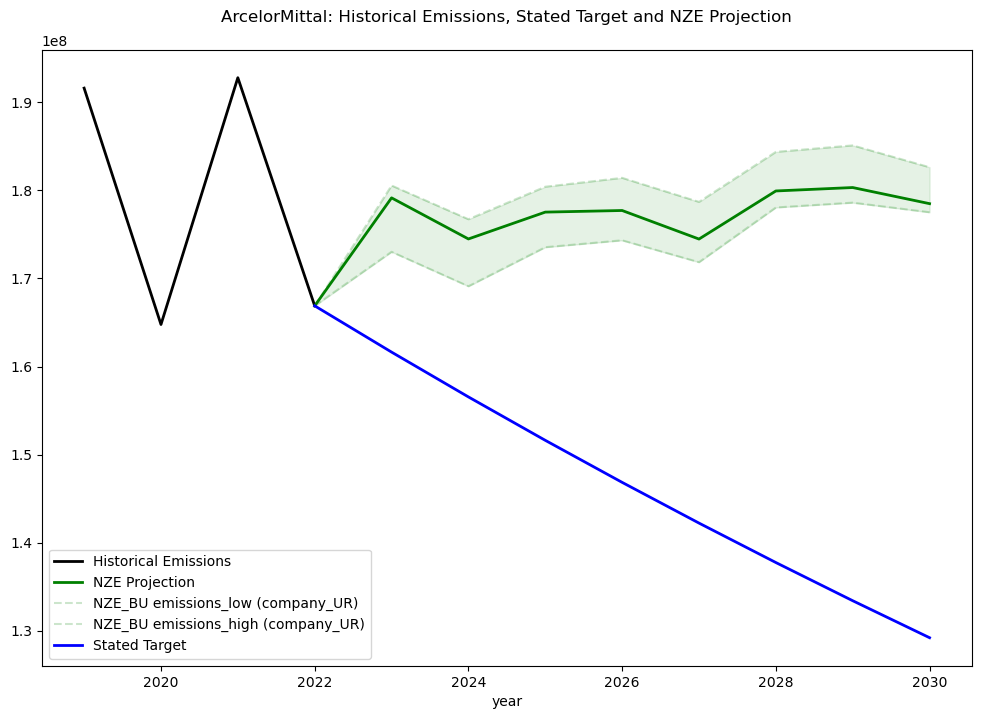

In [16]:
# Extract ArcelorMittal data
arcelor = all_traj.loc[all_traj["Group"]=="ArcelorMittal SA"]
arcelor_hist = group_bu_histo.loc[group_bu_histo["Group"]=="ArcelorMittal SA"]

# Create figure and axis objects
fig, ax = plt.subplots(figsize=(12,8))

# Add title
ax.set_title("ArcelorMittal: Historical Emissions, Stated Target and NZE Projection", pad=20)

# Plot historical emissions
arcelor_hist.plot(x="year", y="BU emissions", ax=ax, label="Historical Emissions", color="black", linewidth=2)

# Plot NZE projection with uncertainty bounds
arcelor.plot(x="year", y="NZE_BU emissions (company_UR)", ax=ax, label="NZE Projection", color="green", linewidth=2)
arcelor.plot(x="year", y="NZE_BU emissions_low (company_UR)", ax=ax, color="green", alpha=0.2, linestyle="--")
arcelor.plot(x="year", y="NZE_BU emissions_high (company_UR)", ax=ax, color="green", alpha=0.2, linestyle="--")
ax.fill_between(arcelor["year"],
                arcelor["NZE_BU emissions_low (company_UR)"],
                arcelor["NZE_BU emissions_high (company_UR)"],
                color="green", alpha=0.1)

# Add stated BU emissions
arcelor.plot(x="year", y="Stated BU emissions", ax=ax, label="Stated Target", color="blue", linewidth=2)

C:\Users\hamada.saleh\AppData\Local\Temp\ipykernel_2152\3302637035.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  all_traj[f"{scenario}_Stated BU emissions"] = all_traj["Stated BU emissions"].copy()
C:\Users\hamada.saleh\AppData\Local\Temp\ipykernel_2152\3302637035.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  all_traj[f"{scenario}_Stated BU emissions"] = all_traj["Stated BU emissions"].copy()
C:\Users\hamada.saleh\AppData\Local\Temp\ipykernel_2152\3302637035.py:17: SettingWithCopyWarning: 
A v

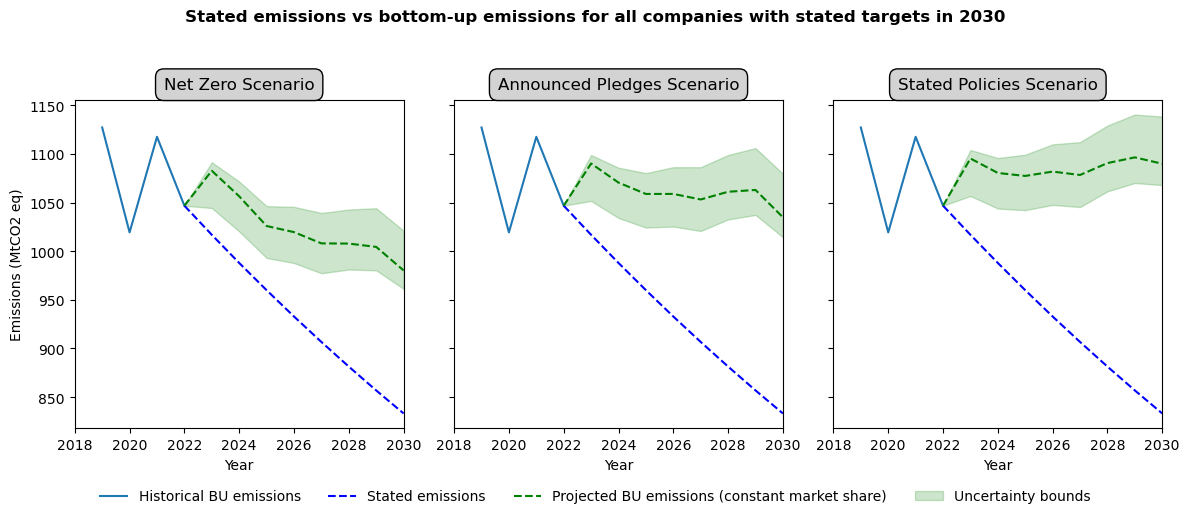

In [17]:

# Remove specific company if needed
all_traj = all_traj.loc[all_traj["Group"] != "Ternium SA"]

### 6. Preprocess Combined Data
# Forward fill to make plots continuous
# TODO: check
# all_traj = all_traj.fillna(method="ffill", axis=1)

# Set data types
# dtypes = {'year': int, 'Group': object}
# float_columns = all_traj.columns.difference(['year', 'Group'])
# dtypes.update({col: float for col in float_columns})
# all_traj = all_traj.astype(dtypes)

# Create stated emissions column for each scenario
for scenario in scenarios:
    all_traj[f"{scenario}_Stated BU emissions"] = all_traj["Stated BU emissions"].copy()

### 7. Define Company Subsets
companies_with_stated = list(stated_traj['Group'].unique())
top5_companies = [
    "ArcelorMittal SA", 
    "JSW Steel Ltd", 
    "Nippon Steel Corp", 
    "POSCO Holding Co.", 
    "Shougang Group Co Ltd"
]
# taxonomy_companies = [
#     "Acerinox SA", "Aperam SA", "ArcelorMittal SA", 
#     "Danieli & C Officine Meccaniche SpA", "Outokumpu Oyj", 
#     "Salzgitter AG", "Tenaris SA", "thyssenkrupp AG", "voestalpine AG"
# ]

subsamples = {
    "stated": companies_with_stated, 
    # "top5": top5_companies, 
    # "taxo": taxonomy_companies
}

### 8. Create Comparison Plots (Absolute Emissions)
from src.projections_.targets import get_sub_traj_melt, get_bu_vs_stated_fig

for prefix, companies in subsamples.items():
    sub_traj_melt = get_sub_traj_melt(all_traj, companies)
    
    fig = get_bu_vs_stated_fig(sub_traj_melt, group_bu_histo, companies)
    sub_traj_melt.to_csv(f"./BU_results/plots_data/{prefix}_single_stated_traj_scenarios_EAF_decarb.csv")
    fig_path = Path("./BU_results/plots") / f"{prefix}_single_stated_traj_scenarios_EAF_decarb.pdf"
    fig.savefig(fig_path, bbox_inches='tight', dpi=600)


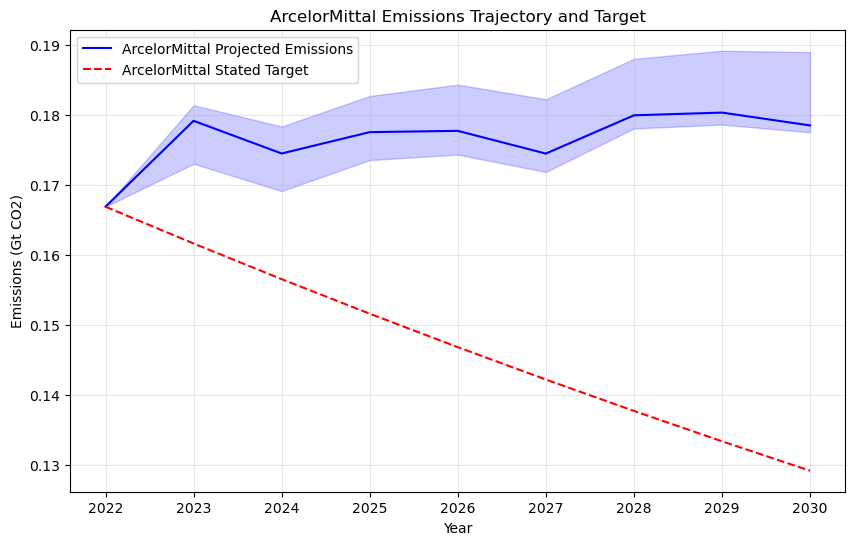

In [18]:
# Extract ArcelorMittal trajectory from merged data
arcelor_traj = all_traj[all_traj['Group'] == 'ArcelorMittal SA']

# Create figure and axis
plt.figure(figsize=(10, 6))

# Plot projected trajectory
plt.plot(arcelor_traj['year'], arcelor_traj['NZE_BU emissions (company_UR)'] / 1e9,
         label='ArcelorMittal Projected Emissions', color='blue')

# Plot uncertainty bounds
plt.fill_between(arcelor_traj['year'],
                 arcelor_traj['NZE_BU emissions_low (company_UR)'] / 1e9,
                 arcelor_traj['NZE_BU emissions_high (company_UR)'] / 1e9,
                 alpha=0.2, color='blue')

# Plot stated trajectory
plt.plot(arcelor_traj['year'], arcelor_traj['Stated BU emissions'] / 1e9,
         label='ArcelorMittal Stated Target', color='red', linestyle='--')

# Customize plot
plt.xlabel('Year')
plt.ylabel('Emissions (Gt CO2)')
plt.title('ArcelorMittal Emissions Trajectory and Target')
plt.legend()
plt.grid(True, alpha=0.3)

# Show plot
plt.show()


In [19]:
arcelor_traj

,year,Group,Stated BU emissions,NZE_BU emissions (company_UR),NZE_BU emissions_low (company_UR),NZE_BU emissions_high (company_UR),APS_BU emissions (company_UR),APS_BU emissions_low (company_UR),APS_BU emissions_high (company_UR),STEPS_BU emissions (company_UR),STEPS_BU emissions_low (company_UR),STEPS_BU emissions_high (company_UR),NZE_Stated BU emissions,APS_Stated BU emissions,STEPS_Stated BU emissions
27,2022,ArcelorMittal SA,1.668848e+08,1.668848e+08,1.668848e+08,1.668848e+08,1.668848e+08,1.668848e+08,1.668848e+08,1.668848e+08,1.668848e+08,1.668848e+08,1.668848e+08,1.668848e+08,1.668848e+08
28,2023,ArcelorMittal SA,1.616348e+08,1.791346e+08,1.730131e+08,1.813594e+08,1.802615e+08,1.741106e+08,1.816686e+08,1.810825e+08,1.749087e+08,1.824948e+08,1.616348e+08,1.616348e+08,1.616348e+08
29,2024,ArcelorMittal SA,1.565499e+08,1.744715e+08,1.691078e+08,1.783213e+08,1.766402e+08,1.712252e+08,1.788999e+08,1.782390e+08,1.727839e+08,1.805153e+08,1.565499e+08,1.565499e+08,1.565499e+08
30,2025,ArcelorMittal SA,1.516249e+08,1.775180e+08,1.735355e+08,1.826687e+08,1.806360e+08,1.760024e+08,1.836777e+08,1.828579e+08,1.781777e+08,1.859303e+08,1.516249e+08,1.516249e+08,1.516249e+08
31,2026,ArcelorMittal SA,1.468549e+08,1.777001e+08,1.743176e+08,1.842950e+08,1.811346e+08,1.770875e+08,1.850239e+08,1.841137e+08,1.800115e+08,1.880560e+08,1.468549e+08,1.468549e+08,1.468549e+08
32,2027,ArcelorMittal SA,1.422350e+08,1.744606e+08,1.718364e+08,1.822008e+08,1.788006e+08,1.755411e+08,1.832259e+08,1.826306e+08,1.793126e+08,1.871353e+08,1.422350e+08,1.422350e+08,1.422350e+08
33,2028,ArcelorMittal SA,1.377604e+08,1.799166e+08,1.780428e+08,1.879717e+08,1.847070e+08,1.822593e+08,1.893701e+08,1.892898e+08,1.867899e+08,1.940526e+08,1.377604e+08,1.377604e+08,1.377604e+08
34,2029,ArcelorMittal SA,1.334266e+08,1.803059e+08,1.785910e+08,1.891291e+08,1.860128e+08,1.837219e+08,1.910586e+08,1.913093e+08,1.889618e+08,1.964796e+08,1.334266e+08,1.334266e+08,1.334266e+08
35,2030,ArcelorMittal SA,1.292291e+08,1.784766e+08,1.775005e+08,1.889299e+08,1.838312e+08,1.823174e+08,1.886166e+08,1.886288e+08,1.865851e+08,1.936578e+08,1.292291e+08,1.292291e+08,1.292291e+08


In [20]:
### Step 2: Load and preprocess Refinitiv data for baseline emissions

In [21]:
### Step 4: Create stated emission trajectories (2022-2030)

In [22]:
### Step 5: Prepare nze_group to match the format expected by merge_all_traj


# Create a dictionary structure similar to what merge_all_traj expects
# Structure: bu_proj[scenario][method]["company"] = dataframe

# For nze_group, we only have NZE scenario with company_UR method
bu_proj = {
    "NZE": {
        "company_UR": {
            "company": nze_group.copy()
        }
    }
}

# Verify the dataframe has the expected columns
print("Columns in nze_group:")
print(nze_group.columns.tolist())

# The merge_all_traj function expects columns like:
# - year, Group
# - BU emissions (company_UR)
# - BU emissions_low (company_UR) [if uncertainty exists]
# - BU emissions_high (company_UR) [if uncertainty exists]

# Check if uncertainty columns exist
has_uncertainty = ('BU emissions_low (company_UR)' in nze_group.columns and 
                   'BU emissions_high (company_UR)' in nze_group.columns)
print(f"\nUncertainty bounds available: {has_uncertainty}")

In [23]:
### Step 6: Merge stated trajectories with BU projections


In [24]:
### Step 7: Preprocess combined data

In [25]:
# Forward fill to make plots continuous
all_traj = all_traj.fillna(method="ffill", axis=1)

# Set data types
dtypes = {'year': int, 'Group': object}
float_columns = all_traj.columns.difference(['year', 'Group'])
dtypes.update({col: float for col in float_columns})
all_traj = all_traj.astype(dtypes)

# Create stated emissions column for the NZE scenario
all_traj["NZE_Stated BU emissions"] = all_traj["Stated BU emissions"].copy()

print("\nPreprocessed all_traj:")
print(f"  - Shape: {all_traj.shape}")
print(f"  - NaN values: {all_traj.isna().sum().sum()}")

all_traj.head()


Preprocessed all_traj:
  - Shape: (324, 15)
  - NaN values: 0


C:\Users\hamada.saleh\AppData\Local\Temp\ipykernel_13388\148179951.py:2: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  all_traj = all_traj.fillna(method="ffill", axis=1)


,year,Group,Stated BU emissions,NZE_BU emissions (company_UR),NZE_BU emissions_low (company_UR),NZE_BU emissions_high (company_UR),APS_BU emissions (company_UR),APS_BU emissions_low (company_UR),APS_BU emissions_high (company_UR),STEPS_BU emissions (company_UR),STEPS_BU emissions_low (company_UR),STEPS_BU emissions_high (company_UR),NZE_Stated BU emissions,APS_Stated BU emissions,STEPS_Stated BU emissions
0,2022,Acerinox SA,1.276964e+06,1.276964e+06,1.276964e+06,1.276964e+06,1.276964e+06,1.276964e+06,1.276964e+06,1.276964e+06,1.276964e+06,1.276964e+06,1.276964e+06,1.276964e+06,1.276964e+06
1,2023,Acerinox SA,1.251321e+06,1.049918e+06,1.049918e+06,1.182595e+06,1.099555e+06,1.099555e+06,1.099555e+06,1.128904e+06,1.128904e+06,1.128904e+06,1.251321e+06,1.251321e+06,1.251321e+06
2,2024,Acerinox SA,1.226192e+06,9.236398e+05,9.236398e+05,1.171830e+06,1.012958e+06,1.012958e+06,1.012958e+06,1.067684e+06,1.067684e+06,1.067684e+06,1.226192e+06,1.226192e+06,1.226192e+06
3,2025,Acerinox SA,1.201569e+06,8.282453e+05,8.282453e+05,1.183591e+06,9.475554e+05,9.475554e+05,9.475554e+05,1.024327e+06,1.024327e+06,1.024327e+06,1.201569e+06,1.201569e+06,1.201569e+06
4,2026,Acerinox SA,1.177439e+06,7.390768e+05,7.390768e+05,1.189633e+06,8.854420e+05,8.854420e+05,8.854420e+05,9.825428e+05,9.825428e+05,9.825428e+05,1.177439e+06,1.177439e+06,1.177439e+06


### Step 8: Define company subsets for analysis

In [26]:
# All companies with stated targets
companies_with_stated = list(stated_traj['Group'].unique())

# Top 5 emitters
top5_companies = [
    "ArcelorMittal SA", 
    "JSW Steel Ltd", 
    "Nippon Steel Corp", 
    "POSCO Holding Co.", 
    "Shougang Group Co Ltd"
]

# EU Taxonomy companies
taxonomy_companies = [
    "Acerinox SA", "Aperam SA", "ArcelorMittal SA", 
    "Danieli & C Officine Meccaniche SpA", "Outokumpu Oyj", 
    "Salzgitter AG", "Tenaris SA", "thyssenkrupp AG", "voestalpine AG"
]

subsamples = {
    "stated": companies_with_stated, 
    "top5": top5_companies, 
    "taxo": taxonomy_companies
}

print("Company subsets defined:")
for name, companies in subsamples.items():
    print(f"  - {name}: {len(companies)} companies")

Company subsets defined:
  - stated: 37 companies
  - top5: 5 companies
  - taxo: 9 companies


In [27]:
### Step 9: Create plots showing historical trajectories with stated targets and uncertainty bounds


Generating plot for stated subset (37 companies)...
  - sub_traj_melt shape: (54, 6)
  - Scenarios: ['NZE' 'APS' 'STEPS']
  - Sources: ['BU emissions (company_UR)' 'Stated BU emissions']
  - Uncertainty bounds present: True
  ✓ Saved: BU_results\plots\stated_nze_stated_vs_bu_with_uncertainty.pdf
  ✓ Saved: BU_results\plots\stated_nze_stated_vs_bu_with_uncertainty.png


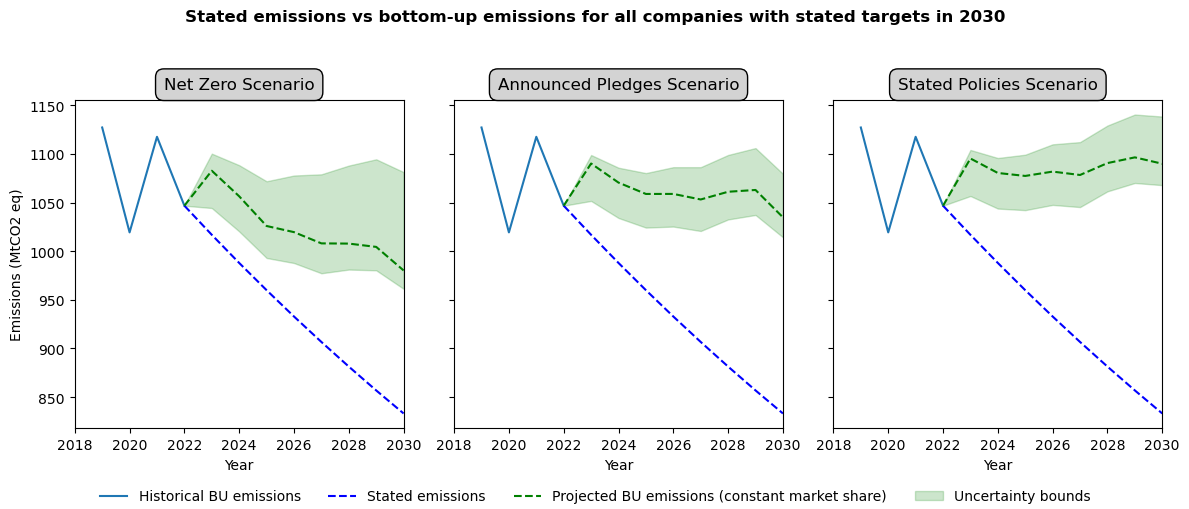


Generating plot for top5 subset (5 companies)...
  - sub_traj_melt shape: (54, 6)
  - Scenarios: ['NZE' 'APS' 'STEPS']
  - Sources: ['BU emissions (company_UR)' 'Stated BU emissions']
  - Uncertainty bounds present: True
  ✓ Saved: BU_results\plots\top5_nze_stated_vs_bu_with_uncertainty.pdf
  ✓ Saved: BU_results\plots\top5_nze_stated_vs_bu_with_uncertainty.png


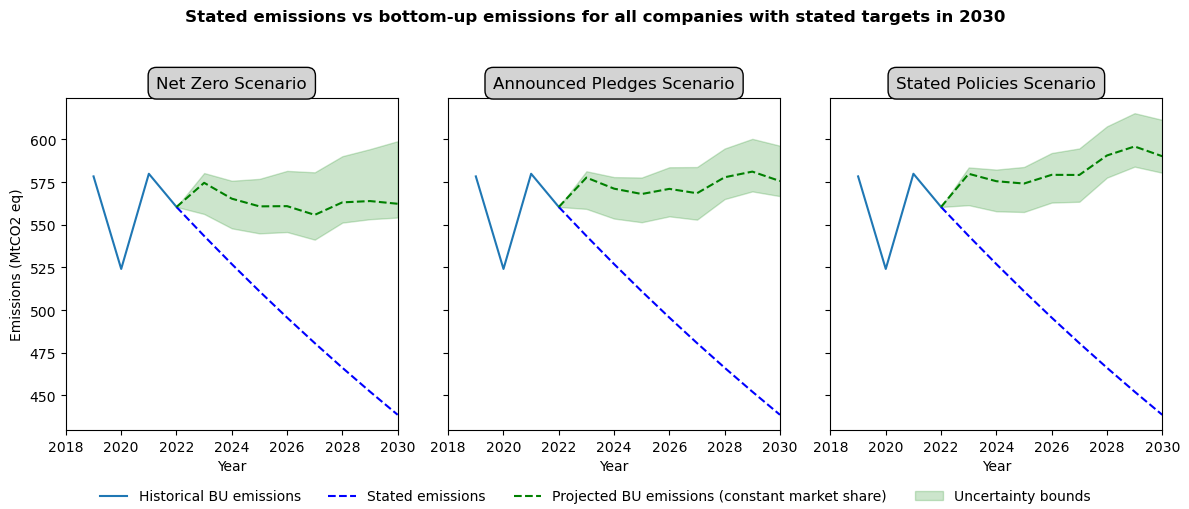


Generating plot for taxo subset (9 companies)...
  - sub_traj_melt shape: (54, 6)
  - Scenarios: ['NZE' 'APS' 'STEPS']
  - Sources: ['BU emissions (company_UR)' 'Stated BU emissions']
  - Uncertainty bounds present: True
  ✓ Saved: BU_results\plots\taxo_nze_stated_vs_bu_with_uncertainty.pdf
  ✓ Saved: BU_results\plots\taxo_nze_stated_vs_bu_with_uncertainty.png


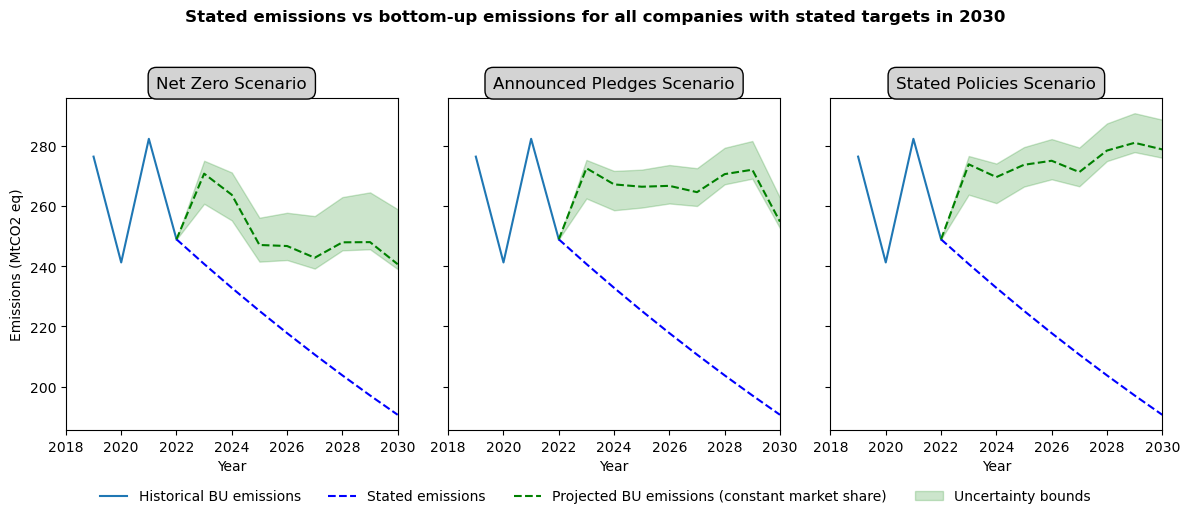


✓ All plots generated successfully!


In [28]:
# Create plots for each company subset
for prefix, companies in subsamples.items():
    print(f"\nGenerating plot for {prefix} subset ({len(companies)} companies)...")
    
    # Get melted trajectory data for this subset
    sub_traj_melt = get_sub_traj_melt(all_traj, companies)
    
    print(f"  - sub_traj_melt shape: {sub_traj_melt.shape}")
    print(f"  - Scenarios: {sub_traj_melt['Scenario'].unique()}")
    print(f"  - Sources: {sub_traj_melt['Source'].unique()}")
    
    # Check if uncertainty bounds are present
    has_uncertainty = 'Emissions_low' in sub_traj_melt.columns and 'Emissions_high' in sub_traj_melt.columns
    print(f"  - Uncertainty bounds present: {has_uncertainty}")
    
    # Create the comparison plot
    fig = get_bu_vs_stated_fig(sub_traj_melt, group_bu_histo, companies)
    
    # Save the plot
    fig_path = plots_dir / f"{prefix}_nze_stated_vs_bu_with_uncertainty.pdf"
    fig.savefig(fig_path, bbox_inches='tight', dpi=600)
    print(f"  ✓ Saved: {fig_path}")
    
    # Also save as PNG for easier viewing
    fig_path_png = plots_dir / f"{prefix}_nze_stated_vs_bu_with_uncertainty.png"
    fig.savefig(fig_path_png, bbox_inches='tight', dpi=300)
    print(f"  ✓ Saved: {fig_path_png}")
    
    plt.show()

print("\n" + "="*70)
print("✓ All plots generated successfully!")
print("="*70)

In [29]:
# Summary statistics of the results
print("\n" + "="*70)
print("SUMMARY STATISTICS")
print("="*70)

# Historical BU emissions for companies with stated targets (2019-2022)
start_year, end_year = 2019, 2022
m1 = group_bu_histo['Group'].isin(companies_with_stated)
m2 = group_bu_histo['year'].between(start_year, end_year)
historical_stated = group_bu_histo.loc[m1 & m2]

print(f"\nHistorical BU emissions ({start_year}-{end_year}):")
print(f"  - Companies with stated targets: {historical_stated['Group'].nunique()}")
print(f"  - Total emissions (MtCO2): {historical_stated['BU emissions'].sum() / 1e6:.1f}")

historical_by_year = historical_stated.groupby('year')['BU emissions'].sum() / 1e6
print("\n  By year (MtCO2):")
for year, emissions in historical_by_year.items():
    print(f"    {year}: {emissions:.1f}")

# Projected emissions for 2030
proj_2030 = all_traj.loc[all_traj['year'] == 2030]
if not proj_2030.empty:
    print(f"\n2030 Projections:")
    if 'NZE_BU emissions (company_UR)' in proj_2030.columns:
        bu_2030 = proj_2030['NZE_BU emissions (company_UR)'].sum() / 1e9
        print(f"  - BU emissions (Gt): {bu_2030:.2f}")
    if 'NZE_Stated BU emissions' in proj_2030.columns:
        stated_2030 = proj_2030['NZE_Stated BU emissions'].sum() / 1e9
        print(f"  - Stated target emissions (Gt): {stated_2030:.2f}")
        if 'NZE_BU emissions (company_UR)' in proj_2030.columns:
            gap = ((bu_2030 - stated_2030) / stated_2030) * 100
            print(f"  - Gap (% overshoot): {gap:.1f}%")


SUMMARY STATISTICS

Historical BU emissions (2019-2022):
  - Companies with stated targets: 36
  - Total emissions (MtCO2): 4310.8

  By year (MtCO2):
    2019: 1127.2
    2020: 1019.3
    2021: 1117.6
    2022: 1046.7

2030 Projections:
  - BU emissions (Gt): 0.98
  - Stated target emissions (Gt): 0.83
  - Gap (% overshoot): 17.7%


In [30]:
# Display sample data for verification
print("\n" + "="*70)
print("SAMPLE DATA")
print("="*70)

print("\n1. Sample companies with stated targets:")
print(targets[['GSPT_Name', 'Percentage', 'CAGR', 'BU emissions']].head(10))

print("\n2. Sample trajectory data:")
sample_companies = companies_with_stated[:3]
for company in sample_companies:
    print(f"\n{company}:")
    company_data = all_traj.loc[all_traj['Group'] == company, 
                                 ['year', 'NZE_Stated BU emissions', 'NZE_BU emissions (company_UR)']]
    print(company_data.head(9))


SAMPLE DATA

1. Sample companies with stated targets:
                        GSPT_Name  Percentage      CAGR  BU emissions
0                     Acerinox SA        20.0 -0.020081  1.276964e+06
1                Aichi Steel Corp        35.0 -0.038405  7.223852e+05
2                       Aperam SA        30.0 -0.022046  2.046135e+06
3                ArcelorMittal SA        25.0 -0.031459  1.668848e+08
4       Benteler International AG        50.0 -0.061069  3.445567e+05
5             BlueScope Steel Ltd        12.0 -0.011554  9.945392e+06
6                China Steel Corp        22.0 -0.020492  3.460026e+07
7            Cleveland-Cliffs Inc        25.0 -0.023688  3.875491e+07
8            Commercial Metals Co        20.0 -0.020081  3.742941e+06
9  Companhia Siderúrgica Nacional        10.0 -0.009533  1.103148e+07

2. Sample trajectory data:

Acerinox SA:
   year  NZE_Stated BU emissions  NZE_BU emissions (company_UR)
0  2022             1.276964e+06                   1.276964e+06
1  20

In [31]:

# Structure: data[scenario][method]["company"] or data[scenario][method]["plant"]
# e.g., firm = data['NZE']["company_UR"]["company"]


targets_path = Path("./data/raw/targets/2030_unique_targets.xlsx")
targets = pd.read_excel(targets_path)

### 3. Preprocess Targets
from src.projections_.targets import preprocess_targets

import json
from pathlib import Path
from src.datasets.RefinitivDataset import RefinitivDataset
from src.datasets.utils import fill_missing_CF12, convert_plant2parent



with open(gspt2gspt_path) as f:
    gspt2gspt = json.load(f)
refi2gspt_path = raw_data_dir / mappings.refi2gspt
refinitiv_path = raw_data_dir / historical_data.top_down.refinitiv
with open(gspt2gspt_path, "r") as f:
    gspt2gspt_map = json.load(f)
# Load Refinitiv data
refi_class = RefinitivDataset(data_path=refinitiv_path)
refinitiv = refi_class.get_preprocessed_data()
refinitiv = fill_missing_CF12(refinitiv=refinitiv, refi2gspt_path=refi2gspt_path, gspt2gspt_map=gspt2gspt_map)

targets = preprocess_targets(
    targets_path=targets_path,
    refinitiv=refinitiv,
    gspt2gspt_path=gspt2gspt_path
)


In [32]:
group_bu_histo.columns

Index(['year', 'Group', 'Attributed emissions (ttpa)',
       'Attributed production (ttpa)', 'country_elec_int', 'EF',
       'EAF_country_elec_int', 'Attributed capacity (ttpa)',
       'Attributed emissions', 'Attributed production',
       'log_Attributed emissions', 'log_Attributed production',
       'elec_int_capa', 'EF_capa', 'EAF_elec_int_capa', 'interaction', 'ratio',
       'log_BU emissions', 'BU emissions'],
      dtype='object')

In [33]:
prod.columns

Index(['Plant ID', 'Plant name (English)', 'Plant name (other language)',
       'Other plant names (English)', 'Other plant names (other language)',
       'SOE status', 'SOE state department', 'Parent', 'Parent PermID',
       'Owner', 'Owner PermID', 'Location address', 'Municipality',
       'Subnational unit (province/state)', 'Country', 'Region',
       'Other language location address', 'Coordinates', 'Coordinate accuracy',
       'GEM wiki page', 'GEM wiki page (other language)', 'Status',
       'Plant age (years)', 'Nominal crude steel capacity (ttpa)',
       'Nominal BOF steel capacity (ttpa)',
       'Nominal EAF steel capacity (ttpa)',
       'Nominal OHF steel capacity (ttpa)', 'Nominal iron capacity (ttpa)',
       'Nominal BF capacity (ttpa)', 'Nominal DRI capacity (ttpa)',
       'Ferronickel capacity (ttpa)', 'Sinter plant capacity (ttpa)',
       'Coking plant capacity (ttpa)', 'Pelletizing plant capacity (ttpa)',
       'Category steel product', 'Steel products', '

In [34]:
prod.groupby(["year", "Main production process"]).agg({"Estimated crude steel production (ttpa)":"sum", "Emissions": "sum"})

Estimated crude steel production (ttpa)  \
year Main production process                                            
2019 electric                                            3.364600e+05   
     electric, oxygen                                    8.363625e+03   
     integrated (BF and DRI)                             5.805384e+04   
     integrated (BF)                                     1.404912e+06   
     integrated (DRI)                                    5.809970e+04   
     integrated (unknown)                                1.028077e+03   
     oxygen                                              8.973808e+03   
2020 electric                                            3.257515e+05   
     electric, oxygen                                    8.662102e+03   
     integrated (BF and DRI)                             5.181792e+04   
     integrated (BF)                                     1.427594e+06   
     integrated (DRI)                                    5.811086e+04   
     integrated (unknown)                                1.105213e+03   
     oxygen                                              8.022055e+03   
2021 electric                                            3.682222e+05   
     electric, oxygen                                    8.996374e+03   
     integrated (BF and DRI)                             5.908920e+04   
     integrated (BF)                                     1.445484e+06   
     integrated (DRI)                                    6.388998e+04   
     integrated (unknown)                                1.079798e+03   
     oxygen                                              1.380312e+04   
2022 electric                                            3.534404e+05   
     electric, oxygen                                    8.256481e+03   
     integrated (BF and DRI)                             5.873596e+04   
     integrated (BF)                                     1.368322e+06   
     integrated (DRI)                                    6.551250e+04   
     integrated (unknown)                                1.042520e+03   
     oxygen                                              2.979284e+04   

                                 Emissions  
year Main production process                
2019 electric                 2.937590e+05  
     electric, oxygen         1.739013e+04  
     integrated (BF and DRI)  1.207089e+05  
     integrated (BF)          3.154666e+06  
     integrated (DRI)         9.586451e+04  
     integrated (unknown)     2.137638e+03  
     oxygen                   1.865886e+04  
2020 electric                 2.945150e+05  
     electric, oxygen         1.801074e+04  
     integrated (BF and DRI)  1.077428e+05  
     integrated (BF)          3.219947e+06  
     integrated (DRI)         9.588293e+04  
     integrated (unknown)     2.298023e+03  
     oxygen                   1.667992e+04  
2021 electric                 3.283692e+05  
     electric, oxygen         1.870578e+04  
     integrated (BF and DRI)  1.228617e+05  
     integrated (BF)          3.249287e+06  
     integrated (DRI)         1.054185e+05  
     integrated (unknown)     2.245178e+03  
     oxygen                   2.870025e+04  
2022 electric                 3.240406e+05  
     electric, oxygen         1.716735e+04  
     integrated (BF and DRI)  1.221272e+05  
     integrated (BF)          3.092506e+06  
     integrated (DRI)         1.080956e+05  
     integrated (unknown)     2.167667e+03  
     oxygen                   6.194699e+04

In [35]:
prod.groupby("year").agg({"Estimated crude steel production (ttpa)":"sum", "Emissions": "sum"})

,Estimated crude steel production (ttpa),Emissions
year,,
2019,1.875891e+06,3.703185e+06
2020,1.881064e+06,3.755077e+06
2021,1.960565e+06,3.855587e+06
2022,1.885102e+06,3.728052e+06


In [36]:
group_bu_histo.groupby("year").agg({"Attributed capacity (ttpa)":"sum", "Attributed production": "sum", "BU emissions": "sum"})

,Attributed capacity (ttpa),Attributed production,BU emissions
year,,,
2019,2.250848e+06,1.875935e+09,4.513524e+09
2020,2.246198e+06,1.881111e+09,4.576444e+09
2021,2.247649e+06,1.960611e+09,4.705377e+09
2022,2.294915e+06,1.885146e+09,4.546489e+09


In [37]:
group_bu_histo.groupby("year").agg({"Attributed capacity (ttpa)":"sum", "Attributed production": "sum", "BU emissions": "sum"})

,Attributed capacity (ttpa),Attributed production,BU emissions
year,,,
2019,2.250848e+06,1.875935e+09,4.513524e+09
2020,2.246198e+06,1.881111e+09,4.576444e+09
2021,2.247649e+06,1.960611e+09,4.705377e+09
2022,2.294915e+06,1.885146e+09,4.546489e+09


In [38]:
display(group_bu_histo.columns)
display(firm.columns)

Index(['year', 'Group', 'Attributed emissions (ttpa)',
       'Attributed production (ttpa)', 'country_elec_int', 'EF',
       'EAF_country_elec_int', 'Attributed capacity (ttpa)',
       'Attributed emissions', 'Attributed production',
       'log_Attributed emissions', 'log_Attributed production',
       'elec_int_capa', 'EF_capa', 'EAF_elec_int_capa', 'interaction', 'ratio',
       'log_BU emissions', 'BU emissions'],
      dtype='object')

NameError: name 'firm' is not defined

In [ ]:
method = "company_UR"
# merge histo and projected emissions
group_bu_histo[f"BU emissions ({method})"] = group_bu_histo["BU emissions"].copy()
group_bu_histo[f"BU emissions_low ({method})"] = group_bu_histo[f"BU emissions ({method})"].copy()
group_bu_histo[f"BU emissions_high ({method})"] = group_bu_histo[f"BU emissions ({method})"].copy()
all_ghg = pd.concat([group_bu_histo[["year", "Group", f"BU emissions ({method})"]], firm], axis=0)

In [ ]:
all_ghg.groupby("year").agg({"BU emissions (company_UR)": "sum"})

,BU emissions (company_UR)
year,
2019,4.513524e+09
2020,4.576444e+09
2021,4.705377e+09
2022,4.546489e+09
2023,4.126313e+09
2024,4.070202e+09
2025,4.014133e+09
2026,3.975520e+09
2027,3.927295e+09


In [ ]:
historical_data

HistoricalDataConfig(version_year=2023, asset_level_data='Global-Steel-Plant-Tracker-2023-03-2.xlsx', missing_years='filled_missing_start_years.xlsx', macro=MacroConfig(iea_prod=WindowsPath('production/WEO_2023'), wsa_prod=WindowsPath('production/global_steel_production.xlsx'), oecd_capa=WindowsPath('capacity/STI_STEEL_MAKINGCAPACITY_08092023132636861.csv'), carbon_price=WindowsPath('carbon_price/Carbon Price Rework 20230405.xlsx')), micro=MicroConfig(company_prod=WindowsPath('production/company_steel_production.xlsx')), top_down=TopDownConfig(refinitiv=WindowsPath('refinitiv_extracts/full_extract_refinitiv_2307.parquet'), cdp=WindowsPath('data/intermediate/cdp_clean.xlsx')))

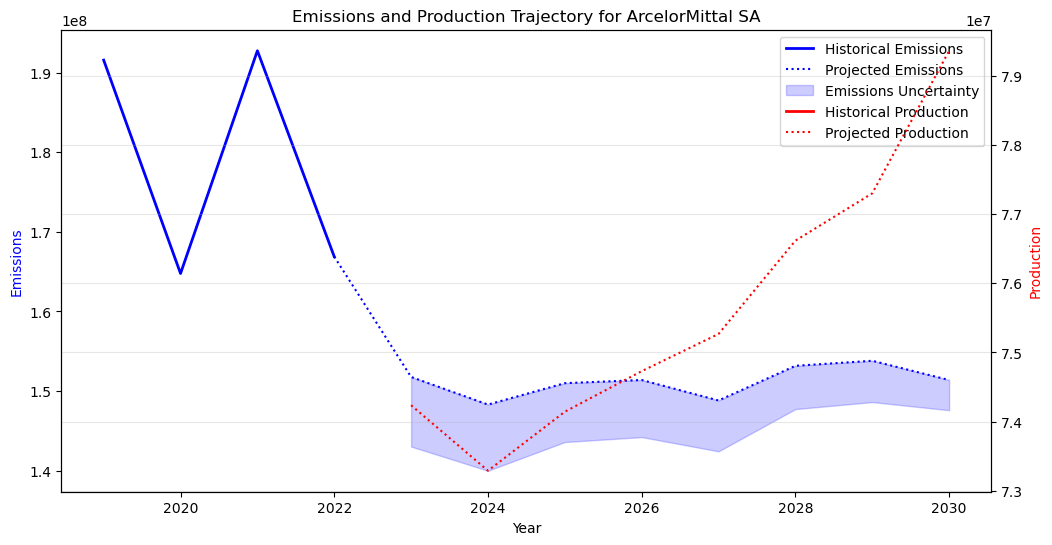

In [ ]:
import matplotlib.pyplot as plt
# Filter for ArcelorMittal SA
arcelor_data = all_ghg[all_ghg['Group'] == 'ArcelorMittal SA']

# Create figure with two y-axes
fig, ax1 = plt.subplots(figsize=(12, 6))
ax2 = ax1.twinx()

# Split data into historical and projected
historical_data = arcelor_data[arcelor_data['year'] <= 2022]
projected_data = arcelor_data[arcelor_data['year'] >= 2022]

# Plot emissions on first y-axis
ax1.plot(historical_data['year'], historical_data['BU emissions (company_UR)'],
         color='blue', label='Historical Emissions', linewidth=2)
ax1.plot(projected_data['year'], projected_data['BU emissions (company_UR)'],
         color='blue', linestyle=':', label='Projected Emissions')
ax1.fill_between(projected_data['year'],
                projected_data['BU emissions_low (company_UR)'],
                projected_data['BU emissions_high (company_UR)'],
                alpha=0.2, color='blue', label='Emissions Uncertainty')

# Plot production on second y-axis
ax2.plot(historical_data['year'], historical_data['production'],
         color='red', label='Historical Production', linewidth=2)
ax2.plot(projected_data['year'], projected_data['production'],
         color='red', linestyle=':', label='Projected Production')

# Add labels and title
ax1.set_xlabel('Year')
ax1.set_ylabel('Emissions', color='blue')
ax2.set_ylabel('Production', color='red')
plt.title('Emissions and Production Trajectory for ArcelorMittal SA')

# Format y-axes to use scientific notation
ax1.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
ax2.ticklabel_format(style='sci', axis='y', scilimits=(0,0))

# Add legends
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

plt.grid(True, alpha=0.3)
plt.show()

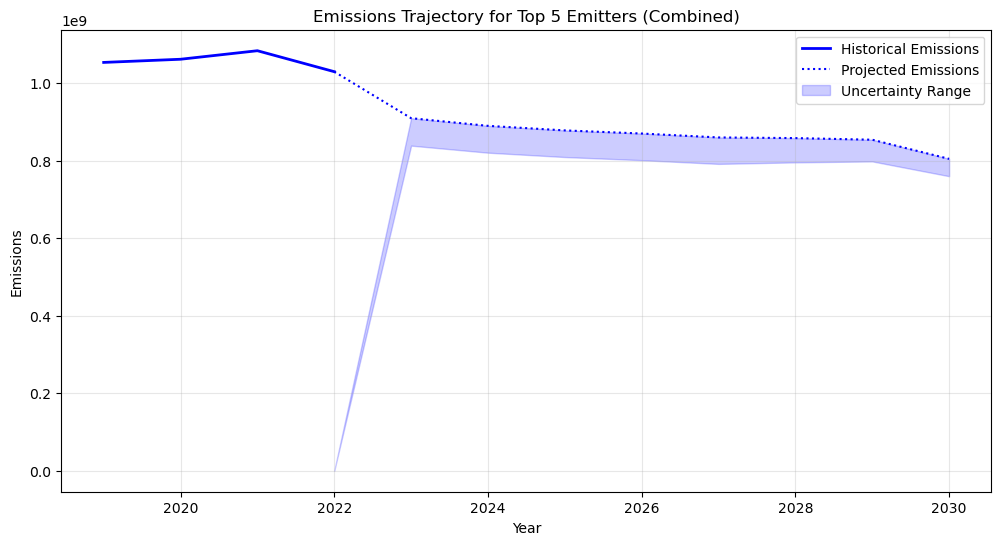

In [ ]:
import matplotlib.pyplot as plt
# Get top 5 emitters based on 2022 emissions
top_5_emitters = all_ghg[all_ghg['year'] == 2023].nlargest(5, 'BU emissions (company_UR)')['Group'].unique()

# Filter data for top 5 emitters and sum their emissions
top_5_data = all_ghg[all_ghg['Group'].isin(top_5_emitters)].groupby('year').agg({
    'BU emissions (company_UR)': 'sum',
    'BU emissions_low (company_UR)': 'sum', 
    'BU emissions_high (company_UR)': 'sum'
}).reset_index()

# Create the plot
plt.figure(figsize=(12, 6))

# Split data into historical and projected
historical_data = top_5_data[top_5_data['year'] <= 2022]
projected_data = top_5_data[top_5_data['year'] >= 2022]

# Plot historical data with solid line
plt.plot(historical_data['year'], historical_data['BU emissions (company_UR)'],
         color='blue', label='Historical Emissions', linewidth=2)

# Plot projected data with dotted line
plt.plot(projected_data['year'], projected_data['BU emissions (company_UR)'],
         color='blue', linestyle=':', label='Projected Emissions')

# Fill between high and low trajectories only for projected period
plt.fill_between(projected_data['year'],
                projected_data['BU emissions_low (company_UR)'],
                projected_data['BU emissions_high (company_UR)'],
                alpha=0.2, color='blue', label='Uncertainty Range')

plt.title('Emissions Trajectory for Top 5 Emitters (Combined)')
plt.xlabel('Year')
plt.ylabel('Emissions')
plt.legend()
plt.grid(True, alpha=0.3)

# Format y-axis to use scientific notation
plt.ticklabel_format(style='sci', axis='y', scilimits=(0,0))

plt.show()


In [42]:
# Save historical emissions for companies with stated targets
print("\n" + "="*70)
print("SAVING HISTORICAL EMISSIONS")
print("="*70)

# Filter historical data for companies with stated targets
historical_stated_companies = group_bu_histo[group_bu_histo['Group'].isin(companies_with_stated)].copy()

# Aggregate by year (sum across all companies with stated targets)
historical_aggregated = historical_stated_companies.groupby('year').agg({
    'BU emissions': 'sum',
    'Attributed production': 'sum',
    'Attributed capacity (ttpa)': 'sum'
}).reset_index()

# Add company count and descriptive columns
historical_aggregated['Number_of_companies'] = historical_stated_companies.groupby('year')['Group'].nunique().values
historical_aggregated['Emissions (Gt)'] = historical_aggregated['BU emissions'] / 1e9
historical_aggregated['Production (Mt)'] = historical_aggregated['Attributed production'] / 1e3
historical_aggregated['Capacity (Mt)'] = historical_aggregated['Attributed capacity (ttpa)'] / 1e3

# Save to Excel
output_path = Path("./BU_results/plots_data/historical_emissions_stated_targets.xlsx")
historical_aggregated.to_excel(output_path, index=False)
print(f"  ✓ Saved: {output_path}")
print(f"\nHistorical emissions for companies with stated targets:")
print(f"  - Number of companies: {historical_stated_companies['Group'].nunique()}")
print(f"  - Years covered: {historical_aggregated['year'].min()} to {historical_aggregated['year'].max()}")
print(f"  - Total 2022 emissions: {historical_aggregated.loc[historical_aggregated['year'] == 2022, 'Emissions (Gt)'].values[0]:.3f} Gt")
print(f"  - Columns: year, BU emissions, Attributed production, Attributed capacity (ttpa), Number_of_companies, Emissions (Gt), Production (Mt), Capacity (Mt)")

print("\n" + "="*70)



SAVING HISTORICAL EMISSIONS
  ✓ Saved: BU_results\plots_data\historical_emissions_stated_targets.xlsx

Historical emissions for companies with stated targets:
  - Number of companies: 36
  - Years covered: 2019 to 2022
  - Total 2022 emissions: 1.047 Gt
  - Columns: year, BU emissions, Attributed production, Attributed capacity (ttpa), Number_of_companies, Emissions (Gt), Production (Mt), Capacity (Mt)



In [33]:

# Merge with 2022 baseline emissions
targets = pd.merge(
    targets,
    all_ghg.loc[all_ghg['year'] == 2022, ["Group", f"BU emissions ({method})"]],
    on="Group",
    how='left'
)


C:\Users\hamada.saleh\AppData\Local\Temp\ipykernel_8384\1898141236.py:25: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  all_traj = all_traj.fillna(method="ffill", axis=1)


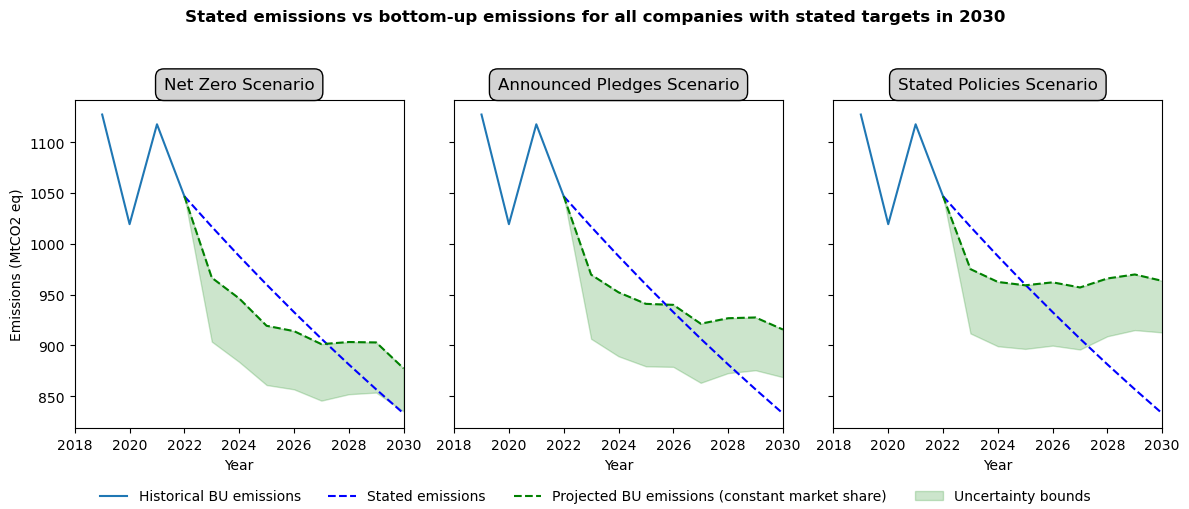

In [ ]:

### 4. Get Stated Trajectories
from src.projections_.targets import get_stated_traj

# Creates emission trajectories from 2022 to 2030 based on stated targets
stated_traj = get_stated_traj(targets=targets, emissions_col=f'BU emissions ({method})')

### 5. Merge All Trajectories


scenarios = ["NZE", "APS", "STEPS"]
methods = ["company_UR"] # constant_UR

all_traj = merge_all_traj(
    stated_traj=stated_traj, 
    bu_proj=data,  # This is the loaded pickle data
    scenarios=scenarios, 
    methods=methods
)

# Remove specific company if needed
all_traj = all_traj.loc[all_traj["Group"] != "Ternium SA"]

### 6. Preprocess Combined Data
# Forward fill to make plots continuous
all_traj = all_traj.fillna(method="ffill", axis=1)

# Set data types
dtypes = {'year': int, 'Group': object}
float_columns = all_traj.columns.difference(['year', 'Group'])
dtypes.update({col: float for col in float_columns})
all_traj = all_traj.astype(dtypes)

# Create stated emissions column for each scenario
for scenario in scenarios:
    all_traj[f"{scenario}_Stated BU emissions"] = all_traj["Stated BU emissions"].copy()

### 7. Define Company Subsets
companies_with_stated = list(stated_traj['Group'].unique())
top5_companies = [
    "ArcelorMittal SA", 
    "JSW Steel Ltd", 
    "Nippon Steel Corp", 
    "POSCO Holding Co.", 
    "Shougang Group Co Ltd"
]
taxonomy_companies = [
    "Acerinox SA", "Aperam SA", "ArcelorMittal SA", 
    "Danieli & C Officine Meccaniche SpA", "Outokumpu Oyj", 
    "Salzgitter AG", "Tenaris SA", "thyssenkrupp AG", "voestalpine AG"
]

subsamples = {
    "stated": companies_with_stated, 
    # "top5": top5_companies, 
    # "taxo": taxonomy_companies
}

### 8. Create Comparison Plots (Absolute Emissions)
from src.projections_.targets import get_sub_traj_melt, get_bu_vs_stated_fig

for prefix, companies in subsamples.items():
    sub_traj_melt = get_sub_traj_melt(all_traj, companies)
    
    fig = get_bu_vs_stated_fig(sub_traj_melt, group_bu_histo, companies)
    sub_traj_melt.to_csv(f"./BU_results/plots_data/{prefix}_single_stated_traj_scenarios_EAF_decarb.csv")
    fig_path = Path("./BU_results/plots") / f"{prefix}_single_stated_traj_scenarios_EAF_decarb.pdf"
    fig.savefig(fig_path, bbox_inches='tight', dpi=600)


In [35]:
sub_traj_melt.columns

Index(['year', 'Source', 'Emissions', 'Scenario', 'Emissions_low',
       'Emissions_high'],
      dtype='object')

In [36]:
cms = sub_traj_melt.loc[(sub_traj_melt["Scenario"] == "NZE") & (sub_traj_melt["Source"] == "Projected BU emissions (constant market share)")]


In [37]:
sub_traj_melt["Source"].unique()

array(['Projected BU emissions (constant market share)',
       'Stated emissions'], dtype=object)

In [38]:
0.97/1.04

0.9326923076923076

In [39]:
cms

,year,Source,Emissions,Scenario,Emissions_low,Emissions_high
0,2022,Projected BU emissions (constant market share),1.046747e+09,NZE,1046746729.97174,1046746729.97174
1,2023,Projected BU emissions (constant market share),9.666220e+08,NZE,903740372.903531,966621976.361839
2,2024,Projected BU emissions (constant market share),9.462283e+08,NZE,883754368.171315,946228323.431721
3,2025,Projected BU emissions (constant market share),9.193351e+08,NZE,861055090.810876,919335119.925612
4,2026,Projected BU emissions (constant market share),9.140907e+08,NZE,856819431.027509,914090656.69254
5,2027,Projected BU emissions (constant market share),9.012869e+08,NZE,845703671.874696,901286892.870705
6,2028,Projected BU emissions (constant market share),9.033661e+08,NZE,852002996.120592,903366126.765531
7,2029,Projected BU emissions (constant market share),9.029635e+08,NZE,853643229.997635,902963450.271305
8,2030,Projected BU emissions (constant market share),8.774088e+08,NZE,835099597.760339,877408787.797627


TypeError: ufunc 'isfinite' not supported for the input types, and the inputs could not be safely coerced to any supported types according to the casting rule ''safe''

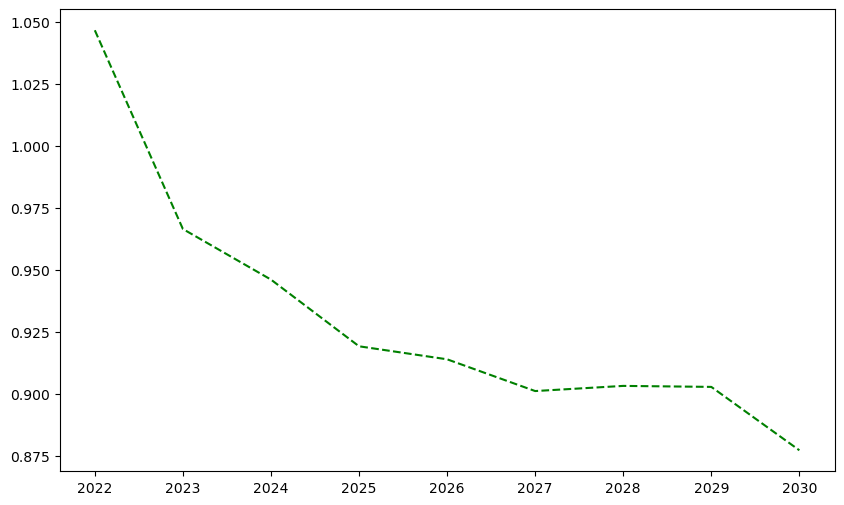

In [40]:

# Plot emissions from constant market share trajectory
plt.figure(figsize=(10,6))
plt.plot(cms['year'], cms['Emissions']/1e9, label='Central estimate', color='green', linestyle='--')

# Add uncertainty bounds if they exist
if 'Emissions_low' in cms.columns and 'Emissions_high' in cms.columns:
    plt.fill_between(cms['year'], 
                     cms['Emissions_low']/1e9,
                     cms['Emissions_high']/1e9, 
                     alpha=0.2,
                     color='green',
                     label='Uncertainty bounds')

plt.xlabel('Year')
plt.ylabel('Emissions (GtCO2 eq)')
plt.title('Projected Bottom-up Emissions with Constant Market Share')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)


In [ ]:
all_ghg.columns

In [ ]:

# ### 9. Create Percentage Misalignment Plots
# ```python
# import matplotlib.pyplot as plt
# import seaborn as sns

# subsamples_df = []

# for prefix, companies in subsamples.items():
#     sub_traj_melt = get_sub_traj_melt(all_traj, companies)
    
#     # Separate BU and stated trajectories
#     bu_sub_traj = sub_traj_melt.loc[sub_traj_melt["Source"] != "Stated emissions"]
#     stated_sub_traj = sub_traj_melt.loc[sub_traj_melt["Source"] == "Stated emissions"]
    
#     # Merge and calculate percentage deviation
#     pct_dev_traj = pd.merge(
#         bu_sub_traj, 
#         stated_sub_traj, 
#         how="left",
#         on=["year", "Scenario"],
#         suffixes=("_bu", "_stated")
#     )
    
#     pct_dev_traj["pct_misalignment"] = 100 * (
#         pct_dev_traj.Emissions_bu - pct_dev_traj.Emissions_stated
#     ) / pct_dev_traj.Emissions_stated
    
#     pct_dev_traj["Subsample"] = prefix
#     subsamples_df.append(pct_dev_traj)

# # Combine all subsamples
# subsamples_df = pd.concat(subsamples_df, axis=0, ignore_index=True)

# # Create subplot grid (2 methods × 3 scenarios)
# fig, axs = plt.subplots(2, 3, figsize=(12, 6), sharey=True)

# for i, method in enumerate(list(subsamples_df['Source_bu'].unique())):
#     for j, scenario in enumerate(scenarios):
#         ax = axs[i, j]
        
#         m1 = subsamples_df["Scenario"] == scenario
#         m2 = subsamples_df["Source_bu"] == method
        
#         sns.lineplot(
#             subsamples_df.loc[m1 & m2],
#             x="year",
#             y="pct_misalignment",
#             hue="Subsample",
#             linestyle="--",
#             ax=ax
#         )
        
#         ax.set_title(scenario)
        
#         if "constant_UR" in method:
#             mname = "country UR"
#         elif "constant market share" in method:
#             mname = "constant market share"
        
#         ax.set_ylabel(f"% overshoot \n ({mname})")
        
#         if (i == 0) & (j == 0):
#             legend_handles_labels = ax.get_legend_handles_labels()
        
#         ax.get_legend().remove()

# title = "Relative deviation of bottom-up projections from the stated emissions trajectory\nfor 3 subsets of companies with stated targets"
# fig.suptitle(title)

# # Create figure-level legend
# handles, labels = legend_handles_labels
# fig.legend(
#     handles=handles, 
#     labels=labels, 
#     loc='outside lower center', 
#     borderaxespad=0., 
#     frameon=False,
#     ncol=3,
# )

# fig.tight_layout()
# fig_path = plots_dir / "pct_misalignment.pdf"
# fig.savefig(fig_path, bbox_inches='tight', dpi=600)
# ```

# ## Key Outputs:
# 1. **Absolute emissions plots**: Stated vs BU emissions for each company subset
# 2. **Percentage misalignment plots**: Shows % overshoot of BU projections relative to stated targets
# 3. **Three subsets analyzed**: 
#    - All companies with stated targets
#    - Top 5 emitters
#    - Taxonomy companies


<!-- # Steps for Stated Targets Analysis

## Overview
This notebook follows the process from `main.py` for comparing stated targets with bottom-up projections.

## Steps:

### 1. Load Bottom-Up Projections (Company-Level)
Already done above - data contains company-level projected emissions.
- Structure: `data[scenario][method]["company"]` or `data[scenario][method]["plant"]`
- Example: `firm = data['NZE']["company_UR"]["company"]`

### 2. Load Stated Targets Data
```python
targets_path = Path("./data/raw/targets/2030_unique_targets.xlsx")
targets = pd.read_excel(targets_path)
```

### 3. Preprocess Targets
```python
from src.targets import preprocess_targets

targets = preprocess_targets(
    targets_path=targets_path,
    refinitiv=refinitiv,
    gspt2gspt_path=gspt2gspt_path
)

# Merge with 2022 baseline emissions
targets = pd.merge(
    targets,
    group_bu_histo.loc[group_bu_histo['year'] == 2022, ["Group", "BU emissions"]],
    on="Group",
    how='left'
)
```

### 4. Get Stated Trajectories
```python
from src.targets import get_stated_traj

# Creates emission trajectories from 2022 to 2030 based on stated targets
stated_traj = get_stated_traj(targets=targets, emissions_col='BU emissions')
```

### 5. Merge All Trajectories
```python
from src.targets import merge_all_traj

scenarios = ["NZE", "APS", "STEPS"]
methods = ["constant_UR", "company_UR"]

all_traj = merge_all_traj(
    stated_traj=stated_traj, 
    bu_proj=data,  # This is the loaded pickle data
    scenarios=scenarios, 
    methods=methods
)

# Remove specific company if needed
all_traj = all_traj.loc[all_traj["Group"] != "Ternium SA"]
```

### 6. Preprocess Combined Data
```python
# Forward fill to make plots continuous
all_traj = all_traj.fillna(method="ffill", axis=1)

# Set data types
dtypes = {'year': int, 'Group': object}
float_columns = all_traj.columns.difference(['year', 'Group'])
dtypes.update({col: float for col in float_columns})
all_traj = all_traj.astype(dtypes)

# Create stated emissions column for each scenario
for scenario in scenarios:
    all_traj[f"{scenario}_Stated BU emissions"] = all_traj["Stated BU emissions"].copy()
```

### 7. Define Company Subsets
```python
companies_with_stated = list(stated_traj['Group'].unique())
top5_companies = [
    "ArcelorMittal SA", 
    "JSW Steel Ltd", 
    "Nippon Steel Corp", 
    "POSCO Holding Co.", 
    "Shougang Group Co Ltd"
]
taxonomy_companies = [
    "Acerinox SA", "Aperam SA", "ArcelorMittal SA", 
    "Danieli & C Officine Meccaniche SpA", "Outokumpu Oyj", 
    "Salzgitter AG", "Tenaris SA", "thyssenkrupp AG", "voestalpine AG"
]

subsamples = {
    "stated": companies_with_stated, 
    "top5": top5_companies, 
    "taxo": taxonomy_companies
}
```

### 8. Create Comparison Plots (Absolute Emissions)
```python
from src.targets import get_sub_traj_melt, get_bu_vs_stated_fig

for prefix, companies in subsamples.items():
    sub_traj_melt = get_sub_traj_melt(all_traj, companies)
    
    fig = get_bu_vs_stated_fig(sub_traj_melt, group_bu_histo, companies)
    
    fig_path = plots_dir / f"{prefix}_single_stated_traj_scenarios_EAF_decarb.pdf"
    fig.savefig(fig_path, bbox_inches='tight', dpi=600)
```

### 9. Calculate Percentage Misalignment
```python
subsamples_df = []

for prefix, companies in subsamples.items():
    sub_traj_melt = get_sub_traj_melt(all_traj, companies)
    
    # Separate BU and stated trajectories
    bu_sub_traj = sub_traj_melt.loc[sub_traj_melt["Source"] != "Stated emissions"]
    stated_sub_traj = sub_traj_melt.loc[sub_traj_melt["Source"] == "Stated emissions"]
    
    # Merge and calculate percentage deviation
    pct_dev_traj = pd.merge(
        bu_sub_traj, 
        stated_sub_traj, 
        how="left",
        on=["year", "Scenario"],
        suffixes=("_bu", "_stated")
    )
    
    pct_dev_traj["pct_misalignment"] = 100 * (
        pct_dev_traj.Emissions_bu - pct_dev_traj.Emissions_stated
    ) / pct_dev_traj.Emissions_stated
    
    pct_dev_traj["Subsample"] = prefix
    subsamples_df.append(pct_dev_traj)

# Combine all subsamples
subsamples_df = pd.concat(subsamples_df, axis=0, ignore_index=True)
```

### 10. Create Percentage Misalignment Plots
```python
import matplotlib.pyplot as plt
import seaborn as sns

# Create subplot grid (2 methods × 3 scenarios)
fig, axs = plt.subplots(2, 3, figsize=(12, 6), sharey=True)

for i, method in enumerate(list(subsamples_df['Source_bu'].unique())):
    for j, scenario in enumerate(scenarios):
        ax = axs[i, j]
        
        m1 = subsamples_df["Scenario"] == scenario
        m2 = subsamples_df["Source_bu"] == method
        
        sns.lineplot(
            subsamples_df.loc[m1 & m2],
            x="year",
            y="pct_misalignment",
            hue="Subsample",
            linestyle="--",
            ax=ax
        )
        
        ax.set_title(scenario)
        
        if "constant_UR" in method:
            mname = "country UR"
        elif "constant market share" in method:
            mname = "constant market share"
        
        ax.set_ylabel(f"% overshoot ({mname})")
        
        if (i == 0) & (j == 0):
            legend_handles_labels = ax.get_legend_handles_labels()
        
        ax.get_legend().remove()

title = "Relative deviation of bottom-up projections from stated emissions trajectory"
fig.suptitle(title)

# Create figure-level legend
handles, labels = legend_handles_labels
fig.legend(
    handles=handles, 
    labels=labels, 
    loc='outside lower center', 
    borderaxespad=0., 
    frameon=False,
    ncol=3,
)

fig.tight_layout()
fig_path = plots_dir / "pct_misalignment.pdf"
fig.savefig(fig_path, bbox_inches='tight', dpi=600)
```

## Key Outputs:
1. **Absolute emissions plots**: Stated vs BU emissions for each company subset
2. **Percentage misalignment plots**: Shows % overshoot of BU projections relative to stated targets
3. **Three subsets analyzed**: 
   - All companies with stated targets
   - Top 5 emitters
   - Taxonomy companies -->
